In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##  Versions of used packages

We will check PyTorch version to make sure everything work properly.

We use `python==3.7.14`, `torch==1.12.1+cu113` and `torchvision==0.13.1+cu113`. This is the default version in Google Colab.

In [8]:
import sys
import torch
import torchvision
print('python', sys.version.split('\n')[0])
print('torch', torch.__version__)
print('torchvision', torchvision.__version__)

python 3.8.16 (default, Dec  7 2022, 01:12:13) 
torch 1.13.0+cu116
torchvision 0.14.0+cu116


# Prepare Data

In [9]:
!unzip -qq ./drive/MyDrive/Deep\ Learning/assignment3/A3_data_flower_2022.zip

replace A3_data_flower_2022/val.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [10]:
data_folder = 'A3_data_flower_2022'

## Loading the dataset


In [11]:
import csv
import os
import numpy as np
from PIL import Image
import torch

class FlowerData(torch.utils.data.Dataset):
    def __init__(self, csv_file, mode='train', transform=None):
        self.mode = mode # 'train', 'val' or 'test'
        self.data_list = []
        self.labels = []
        self.transform = transform
        
        with open(f'{data_folder}/{csv_file}', newline='') as csvfile:
            reader = csv.DictReader(csvfile)
            for row in reader:
                self.data_list.append(f"{data_folder}/{row['file_path']}")
                if mode != 'test':
                    self.labels.append(row['label'])

    def __getitem__(self, index):
        data = Image.open(self.data_list[index])
        if self.transform is not None:
            data = self.transform(data)
        if self.mode == 'test':
            return data
        label = torch.tensor(int(self.labels[index]))

        return data, label

    def __len__(self):
        return len(self.data_list)

In [13]:
from torchvision import transforms
import random
import matplotlib.pyplot as plt
import numpy as np
# For TRAIN

transforms_train =transforms.Compose([
  transforms.RandomResizedCrop(224),
  transforms.RandomHorizontalFlip(0.5),
  transforms.RandomRotation(10),
  transforms.ToTensor(),
  transforms.Normalize([0.485, 0.456, 0.406], 
                      [0.229, 0.224, 0.225]) 
 ])

# For VAL, TEST
transforms_test = transforms.Compose([
  transforms.Resize([224, 224]),
  transforms.ToTensor(),
  transforms.Normalize([0.485, 0.456, 0.406], 
            [0.229, 0.224, 0.225])
])

In [14]:
dataset_train = FlowerData('train.csv', mode='train', transform=transforms_train)
dataset_val = FlowerData('val.csv', mode='val', transform=transforms_test)
dataset_test = FlowerData('test.csv', mode='test', transform=transforms_test)

In [15]:
print("The first image's shape in dataset_train :", dataset_train[0][0].size())
print("There are", len(dataset_train), "images in dataset_train.")

The first image's shape in dataset_train : torch.Size([3, 224, 224])
There are 3022 images in dataset_train.


In [16]:
from torch.utils.data import DataLoader

batch_size = 32
num_workers = 2
train_loader = DataLoader(dataset_train, batch_size=batch_size, num_workers=num_workers, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=batch_size, num_workers=num_workers, shuffle=False)
test_loader = DataLoader(dataset_test, batch_size=batch_size, num_workers=num_workers, shuffle=False)

TypeError: ignored

Finally! We have made all data prepared.  
Let's go develop our model.

# Implement CNN using PyTorch

In [17]:
import torch.nn as nn 
import torch.nn.functional as F

class YourCNNModel(nn.Module): 
    def __init__(self): 
        super().__init__()
        
        self.cnn_model = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, stride = 1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 128, 3, stride = 1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.2),

            nn.Conv2d(128, 128, 3, stride = 1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.2),

            nn.Conv2d(128, 256, 3, stride = 1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.2),

            nn.Conv2d(256, 256, 3, stride = 1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc_model = nn.Sequential(
            nn.Linear(256*3*3, 500),
            nn.Dropout(0.2),
            nn.ReLU(),
            nn.Linear(500, 5)
        )

    def forward(self, x): 
        if not isinstance(x, torch.Tensor):
            x = torch.Tensor(x)

        x = self.cnn_model(x)
        # print(x.shape)
        x = x.view(x.size(0), -1)
        x = self.fc_model(x)
        out = F.log_softmax(x, dim = 1)

        return out

In [18]:

device = torch.device('cuda')
# or
# device = torch.device('cpu')

In [19]:
model = YourCNNModel()
model = model.to(device)
# print(model)

### Define loss and optimizer

In [20]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=2e-5)

criterion = criterion.to(device)

### Train the model

#### Train function
Let's define train function.  
It will iterate input data 1 epoch and update model with optmizer.  
Finally, calculate mean loss and total accuracy.

Hint: [torch.max()](https://pytorch.org/docs/stable/generated/torch.max.html#torch-max) or [torch.argmax()](https://pytorch.org/docs/stable/generated/torch.argmax.html)

In [21]:
def train(input_data, model, criterion, optimizer):
    '''
    Argement:
    input_data -- iterable data, typr torch.utils.data.Dataloader is prefer
    model -- nn.Module, model contain forward to predict output
    criterion -- loss function, used to evaluate goodness of model
    optimizer -- optmizer function, method for weight updating
    '''
    model.train()
    loss_list = []
    total_count = 0
    acc_count = 0
    for images, labels in input_data:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        total_count += labels.size(0)
        acc_count += (predicted == labels).sum().item()
        loss_list.append(loss.item())

    # Compute this epoch accuracy and loss
    acc = acc_count / total_count
    loss = sum(loss_list) / len(loss_list)
    return acc, loss

#### Validate function
Next part is validate function.  
It works as training function without optmizer and weight-updating part.

In [22]:
def val(input_data, model, criterion):
    model.eval()
    
    loss_list = []
    total_count = 0
    acc_count = 0
    with torch.no_grad():
        for images, labels in input_data:
            images = images.to(device)
            labels = labels.to(device)

            ####################################################################
            # TODO: Get the predicted result and loss                          #
            # 1. process input through the network                             #
            # 2. compute the loss                                              #
            # 3. get the model predicted result                                #
            # 4. get the counts of correctly classified images                 #
            # 5. save this batch's loss into loss_list                         #
            ####################################################################
            outputs = model(images)
            loss = criterion(outputs, labels)
            _, predicted = torch.max(outputs.data, 1)
            total_count += labels.size(0)
            acc_count += (predicted == labels).sum().item()
            loss_list.append(loss.item())
            ####################################################################
            #                         End of your code                         #
            ####################################################################

    acc = acc_count / total_count
    loss = sum(loss_list) / len(loss_list)
    return acc, loss

#### Training in a loop
Call train and test function in a loop.  
Take a break and wait.

In [23]:
################################################################################
# You can adjust those hyper parameters to loop for max_epochs times           #
################################################################################
max_epochs = 100
log_interval = 2 # print acc and loss in per log_interval time

train_acc_list = []
train_loss_list = []
val_acc_list = []
val_loss_list = []

for epoch in range(1, max_epochs + 1):
    train_acc, train_loss = train(train_loader, model, criterion, optimizer)
    val_acc, val_loss = val(val_loader, model, criterion)

    train_acc_list.append(train_acc)
    train_loss_list.append(train_loss)
    val_acc_list.append(val_acc)
    val_loss_list.append(val_loss)
    if epoch % log_interval == 0:
        print('=' * 20, 'Epoch', epoch, '=' * 20)
        print('Train Acc: {:.6f} Train Loss: {:.6f}'.format(train_acc, train_loss))
        print('  Val Acc: {:.6f}   Val Loss: {:.6f}'.format(val_acc, val_loss))

################################################################################
#                               End of your code                               #
################################################################################

==================== Epoch 2 ====================
Train Acc: 0.393779 Train Loss: 1.349200
  Val Acc: 0.447277   Val Loss: 1.300425
==================== Epoch 4 ====================
Train Acc: 0.451688 Train Loss: 1.216277
  Val Acc: 0.488992   Val Loss: 1.189539
==================== Epoch 6 ====================
Train Acc: 0.477829 Train Loss: 1.175544
  Val Acc: 0.521437   Val Loss: 1.144079
==================== Epoch 8 ====================
Train Acc: 0.504633 Train Loss: 1.142021
  Val Acc: 0.504056   Val Loss: 1.143817
==================== Epoch 10 ====================
Train Acc: 0.523163 Train Loss: 1.132293
  Val Acc: 0.509849   Val Loss: 1.128166
==================== Epoch 12 ====================
Train Acc: 0.554600 Train Loss: 1.089865
  Val Acc: 0.537659   Val Loss: 1.088041
==================== Epoch 14 ====================
Train Acc: 0.567174 Train Loss: 1.053121
  Val Acc: 0.515643   Val Loss: 1.089032
==================== Epoch 16 ====================
Train Acc: 0.572469 Tr

In [24]:
  # save your well-trained state_dict of model
torch.save(model.state_dict(), 'NAME_OF_THIS_EXPERIMENT.pt')

#### Visualize accuracy and loss

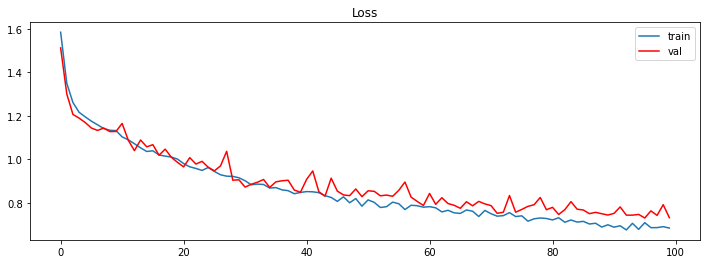

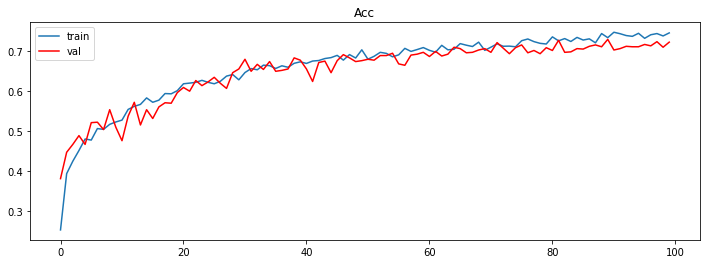

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(range(len(train_loss_list)), train_loss_list)
plt.plot(range(len(val_loss_list)), val_loss_list, c='r')
plt.legend(['train', 'val'])
plt.title('Loss')
plt.show()
plt.figure(figsize=(12, 4))
plt.plot(range(len(train_acc_list)), train_acc_list)
plt.plot(range(len(val_acc_list)), val_acc_list, c='r')
plt.legend(['train', 'val'])
plt.title('Acc')
plt.show()

In [ ]:
ckpt = torch.load('NAME_OF_THIS_EXPERIMENT.pt')
model.load_state_dict(ckpt) 

In [129]:
def load_data(path):
  img = Image.open(path)
  convert_tensor = transforms.Compose([transforms.Resize([224, 224]),
                              transforms.ToTensor(),
                              transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),])

  img = convert_tensor(img)
  img = img.unsqueeze(0)
  return img

img = load_data("./A3_data_flower_2022/test/10386702973_e74a34c806_n.jpg")

In [130]:
def predict(images, model):
    model.eval()
    output_list = []
    with torch.no_grad():
          images = images.to(device)
          outputs = model(images)
          _, predicted = torch.max(outputs.data, 1)
          output = predicted.item()
    return output



In [131]:
result = predict(img, model)
result

3